# Imaging a modulation

A spin density wave, a screened impurity, a domain wall: each of them is a slow
envelope on a crystal that is still atomically periodic, and the way one is
actually seen is with a scanning-tunnelling microscope. The previous notebook
computes such a wave in the unit cell's own states; this one looks at it the way
an experiment would.

In the Tersoff-Hamann picture the current an s-wave tip draws is the sample's
local density of states at the tip, at the energy the bias selects, so the image
is the same density read with a smeared delta at the tip energy in place of the
occupations. The states that made the wave are the ones that make the image.

**What a tip measures is not the charge density**, and a magnetic wave is where
the difference shows. A tip polarized along the wave's axis sees the wave itself,
one period over the eight cells, and reversing the tip gives the image shifted by
half a period, which is the other spin channel. An unpolarized tip does not see
nothing: it sees the wave squared, **two** periods over the eight cells, because
a collinear crystal is unchanged by flipping every spin at the same time as the
sign of the applied field, so the charge cannot respond at first order and its
leading response is at twice the wavevector. On a cell carrying 0.12 Bohr
magnetons the two come out at **82 per cent** and **37 per cent** of their means
from cell to cell, on a charge density that is itself modulated by far less: the
density of states at one energy is a much more sensitive quantity than the
density.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from defumat import Calculator

magnetic = Calculator.from_file('../tests/data/qe/si-ultracell-mag.in',
                                pseudo_dir='../tests/data/pseudo')
field = lambda x: 0.02 * np.cos(2 * np.pi * x[..., 0] / 8)
wave = magnetic.get_ultracell(supercell=(8, 1, 1), kgrid=(1, 2, 2), nbnd=32,
                              magnetic_field=field, david=2, states_conv_thr=1e-5)
print(f'largest cell moment {np.abs(wave.cell_moments()).max():.4f} mu_B')

[defumat] an ultracell calculation: no ground state cached, running the SCF first (conv_thr = 1e-10). Call get_scf() to do this explicitly.


/u/40/ladovj1/data/Documents/programs/claude/defumat/defumat/ultracell/driver.py:561: UserWarning: the fixed-density solve did not converge at 14 of 64 k-points: up to 2 of 32 bands are unsettled and the worst k-point took 100 Davidson steps, at ethr = 1.3e-07 (from conv_thr = 1.0e-05). There is no later iteration to fix this -- the density is fixed -- so these wavefunctions are what every quantity built on them will use. Loosen conv_thr (ethr is 0.1 x conv_thr / nelec, QE's setup.f90 rule) before raising the iteration budget: a threshold the solve cannot reach costs the whole budget at every k-point and is where an overlap loses positivity
  calculation, folded_system, eigenvalues, wavefunctions = fixed_density_states(


largest cell moment 0.1223 mu_B


## What the tip is tuned to

The cell is metallic, so the tip sits at the Fermi level and the image is the
zero-bias one: a delta at that energy, as wide as the run's own smearing. A
semiconductor would need a bias instead, since a delta in a gap is identically
zero, and a negative bias then images the filled states below the gap.

`spin` is the tip's own moment. With `polarization = 1` the image is a single
spin channel; with the default of `None` it is the charge, which is what an
ordinary tip measures.

In [2]:
plane = dict(height=0.35, axis=2, shape=(96, 12))
images = {'charge': magnetic.get_ultracell_stm(**plane),
          'one spin channel': magnetic.get_ultracell_stm(spin='up', **plane)}

# the tip's current averaged over each of the eight cells, in units of its mean
def envelope(image):
    per_cell = np.asarray(image.values).mean(axis=1).reshape(8, -1).mean(axis=1)
    return per_cell / per_cell.mean()

for label, image in images.items():
    print(f'{label:17s} varies by {np.ptp(envelope(image)) * 100:6.3f} % '
          f'from cell to cell')


charge            varies by 37.084 % from cell to cell
one spin channel  varies by 81.630 % from cell to cell


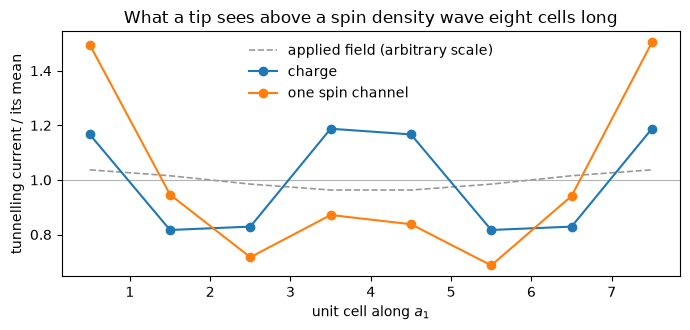

In [3]:
cells = np.arange(8) + 0.5
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.axhline(1.0, color='0.7', lw=0.8)
ax.plot(cells, 1 + 0.04 * np.cos(2 * np.pi * cells / 8), color='0.6', lw=1.2,
        ls='--', label='applied field (arbitrary scale)')
for label, image in images.items():
    ax.plot(cells, envelope(image), 'o-', label=label)
ax.set_xlabel('unit cell along $a_1$')
ax.set_ylabel('tunnelling current / its mean')
ax.set_title('What a tip sees above a spin density wave eight cells long')
ax.legend(frameon=False)
fig.tight_layout()


## Reading it

One spin channel follows the applied field cell by cell, and the other is the
same curve moved four cells along, which is half a period: the two channels are
mirror images and their sum is what an unpolarized tip sees. That sum is not
flat, and its maxima sit where the moment is largest in **magnitude** rather than
where it is largest, which is what "the charge follows the square of the wave"
means when it is read off a picture.

The wave has one period over the eight cells because the applied field does, and
its amplitude is the spin susceptibility at that wavelength: the quantity a
long-period magnet is characterised by, and the one a supercell is too expensive
to reach.

An image like this is a plane through the crystal rather than a surface above it,
because the cell here is bulk silicon. Above a real surface the same quantity is
the image itself, and the tip height is then the distance into the vacuum: the
tunnelling density falls by orders of magnitude across it, which is what makes an
STM sensitive to the outermost layer alone.


## The current that goes through

The same states answer a second question. An electron that enters at the tip and
leaves into a substrate *below* the material has gone through it rather than into
it, and what decides that current is the Green's function between the two points
instead of the density of states at one. `get_ultracell_transport()` computes it,
and it needs a material one cell deep along the stacking direction with the
modulation in the surface plane, which is where a charge density wave or a domain
wall lies in any case. Where several bands are degenerate at the tip energy they
interfere on the way through, and the map departs from the image above by exactly
that interference, which is reported beside it.

The checks live in `tests/regression/test_ultracell_stm.py`: the image of an
unmodulated long cell against the ordinary cell's own image tiled, the sum rule
against the density of states, and the modulated image against a real supercell
run in full, where the disagreement falls from 22 per cent at twelve bands to 2
per cent at forty-eight.